The data is from the 2021 Census of England and Wales and is maintained by the Office for National Statistics. In this notebook, we identify the tradable occupations.

In [16]:
import numpy as np, pandas as pd, geopandas as gpd
from scipy.stats import pearsonr, kendalltau

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

In [ ]:
# Raw data (with 'does not apply' column removed)
df_all = pd.read_csv("data/ew_occupations/raw_data.csv", index_col=0)

# Geodata
gdf = gpd.read_file("data/ew_occupations/la_shapefile.zip")
gdf = gdf.set_index('LAD24CD').loc[df_all.index][['LAD24NM', 'geometry']]

# Occupations
df_occs = pd.read_csv("data/ew_occupations/df_occs_all.csv", index_col=0, dtype={'code':str}).set_index('code')

df_occs['population'] = df_all.sum(axis=0)
df_occs['population'] /= df_occs['population'].sum()

gdf['population'] = df_all.sum(axis=1)
gdf['population'] /= gdf['population'].sum()

Our method is to use Pearson's r. We will compare the results with locational Gini.

In [8]:
df_occs['tradability'] = 1. - df_all.apply(lambda x: pearsonr(gdf['population'], x).statistic)

In [9]:
def get_locational_gini(occ_code):
    rca = ( (df_all[occ_code]/df_all[occ_code].sum()) / gdf['population'] ).to_numpy()
    return np.abs(rca[:, None] - rca).sum() / (318*317*4*rca.mean())

df_occs['loc_gini'] = df_occs.index.map(get_locational_gini)

In [ ]:
pearsonr(df_occs['loc_gini'], df_occs['tradability']), kendalltau(df_occs['loc_gini'], df_occs['tradability'])

(PearsonRResult(statistic=0.962400747801802, pvalue=1.5107752614896678e-59),
 SignificanceResult(statistic=0.8525018670649739, pvalue=1.1925354080948214e-37))

<Axes: xlabel='tradability', ylabel='loc_gini'>

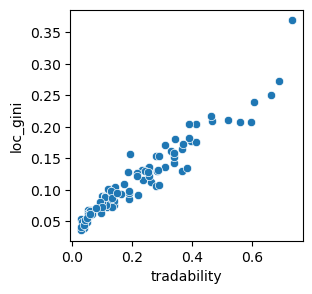

In [14]:
fig, ax = plt.subplots(1,1,figsize=(3, 3))
sns.scatterplot(
    df_occs,
    x = 'tradability',
    y = 'loc_gini',
    ax = ax
)

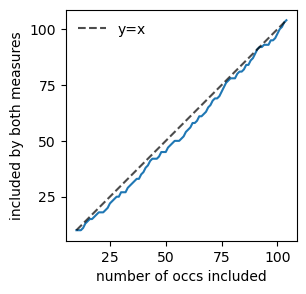

In [13]:
fig, ax = plt.subplots(1,1,figsize=(3, 3))

ax.plot(
    range(10, len(df_occs)+1), 
    [
        len(set(df_occs.sort_values('loc_gini', ascending=False).iloc[:idx].index).intersection(
            set(df_occs.sort_values('tradability', ascending=False).iloc[:idx].index)
        ))
        for idx in range(10, len(df_occs)+1)
    ]
)

ax.plot([10,104], [10,104], '--', c='black', alpha=0.7, label='y=x')
ax.set_xlabel('number of occs included')
ax.set_ylabel('included by both measures')
ax.set_aspect('equal')
ax.set_xticks(range(25, 102, 25))
ax.set_yticks(range(25, 102, 25))
ax.legend(frameon=False)

Number of workers retained vs tradability threshold

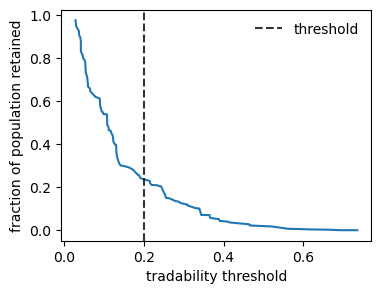

In [15]:
fig, ax = plt.subplots(1,1,figsize=(4, 3))

ax.plot(
    df_occs.sort_values('tradability', ascending=True)['tradability'],
    1 - df_occs.sort_values('tradability', ascending=True)['population'].cumsum()
)
ax.set_xlabel('tradability threshold')
ax.set_ylabel('fraction of population retained')
ax.axvline(0.2, ls='--', label='threshold', color='black', alpha=0.8)
ax.legend(frameon=False)

In [19]:
df_occs[df_occs['tradability']>=0.2]['population'].sum() , (df_occs['tradability']>=0.2).sum()

(0.2421303607369562, 42)

We will also drop 625: Bed and Breakfast and Guest House Owners and Proprietors, which employs 7,354 people, i.e. 0.026% of the workforce

In [20]:
df_occs_trad = df_occs[df_occs['tradability']>=0.2].drop(columns=['tradability', 'loc_gini']).copy()
df_occs_trad = df_occs_trad.drop(index='625')
df_trad = df_all[df_occs_trad.index].copy()

In [21]:
df_occs_trad.loc[:, 'population'] /= df_occs_trad['population'].sum()
gdf['n_population'] = df_trad.sum(axis=1)
gdf['population'] = gdf['n_population'] / gdf['n_population'].sum()
df_vectors = df_trad / df_trad.sum(axis=1).to_numpy()[:, np.newaxis]

In [22]:
df_vectors.to_csv('outputs/ew_occupations/df_vectors.csv')
df_occs_trad.to_csv('outputs/ew_occupations/df_occs.csv')
df_trad.to_csv('outputs/ew_occupations/df_trad.csv')